# 06 · Time series in pandas

Cheat sheet for hourly / daily data: indexing, timezones, resampling, gaps, shifts, rolling
windows and the leakage patterns that follow from them.

**What's in here**
- DatetimeIndex basics: `set_index`, `sort_index`, monotonic / unique checks
- Partial string indexing, `.dt` accessor
- Timezones: UTC storage, `tz_convert` vs `tz_localize`, DST duplicate & missing local hours
- `asfreq` vs `resample`, `label` / `closed`, upsampling
- Detecting gaps: `infer_freq`, `diff().value_counts()`, `reindex(date_range)`
- `shift(n)` vs `shift(freq=)` — and why they differ with missing hours
- `rolling(24)` vs `rolling("24h")`, `min_periods`, `expanding`, `ewm`
- The leakage pattern: `shift(1).rolling(24)` vs `rolling(24)`
- `pct_change` on prices that can go negative
- Hour-of-day profiles, year-on-year pivots, `between_time`, business days
- Calendar features

In [1]:
import numpy as np
import pandas as pd

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 3)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"])
print(df.dtypes)
df.head(3)

time               datetime64[ns, UTC]
consumption_mwh                float64
temp_c                         float64
wind_ms                        float64
solar_wm2                      float64
price_eur_mwh                  float64
dtype: object


,time,consumption_mwh,temp_c,wind_ms,solar_wm2,price_eur_mwh
0,2022-01-01 00:00:00+00:00,26858.4,0.11,7.00,0.0,81.83
1,2022-01-01 01:00:00+00:00,26177.8,-0.18,6.61,0.0,88.21
2,2022-01-01 02:00:00+00:00,26229.4,-1.11,7.14,0.0,84.71


## DatetimeIndex: set it, sort it, check it

Almost every time-series method assumes a **sorted, unique** DatetimeIndex. Check both explicitly:
`is_monotonic_increasing` and `is_unique`. Unsorted data silently breaks `shift`, `rolling`,
`merge_asof` and partial string slicing.

In [2]:
ts = df.set_index("time").sort_index()
print("monotonic:", ts.index.is_monotonic_increasing, "| unique:", ts.index.is_unique)
print("range:", ts.index.min(), "->", ts.index.max(), "| rows:", len(ts))
print("tz:", ts.index.tz, "| inferred freq:", pd.infer_freq(ts.index))

monotonic: True | unique: True
range: 2022-01-01 00:00:00+00:00 -> 2023-12-31 23:00:00+00:00 | rows: 17520
tz: UTC | inferred freq: h


## Partial string indexing

With a DatetimeIndex, `.loc["2022-03"]` selects the whole month and `.loc["2022-03-27"]` the whole
day. Slices are inclusive at both ends. Works only on a sorted index.

In [3]:
print(ts.loc["2022-03"].shape, " <- March 2022")
print(ts.loc["2022-03-27"].shape, " <- one day")
print(ts.loc["2022-03-27 06:00":"2022-03-27 09:00"].shape, " <- inclusive slice")
ts.loc["2023-12-31 20:00":].round(1)

(744, 5)  <- March 2022
(24, 5)  <- one day
(4, 5)  <- inclusive slice


,consumption_mwh,temp_c,wind_ms,solar_wm2,price_eur_mwh
time,,,,,
2023-12-31 20:00:00+00:00,32803.0,4.6,7.8,0.0,130.0
2023-12-31 21:00:00+00:00,30263.2,3.9,7.0,0.0,77.7
2023-12-31 22:00:00+00:00,28415.8,3.3,8.2,0.0,85.8
2023-12-31 23:00:00+00:00,27054.8,2.4,8.1,0.0,56.8


## The `.dt` accessor (on a column) vs index attributes

On a Series: `s.dt.hour`. On the index: `ts.index.hour`. Same fields: `hour, dayofweek, month,
dayofyear, date, is_month_end, days_in_month, quarter`.

In [4]:
feat = pd.DataFrame({
    "hour": df["time"].dt.hour,
    "dow": df["time"].dt.dayofweek,        # Monday=0
    "month": df["time"].dt.month,
    "date": df["time"].dt.date,            # python date objects -> object dtype, slow
    "month_end": df["time"].dt.is_month_end,
})
feat.index = df["time"]     # NB: passing index=df["time"] in the constructor would align on labels -> all NaN
feat.iloc[[0, 23, 24, 700, -1]]

,hour,dow,month,date,month_end
time,,,,,
2022-01-01 00:00:00+00:00,0,5,1,2022-01-01,False
2022-01-01 23:00:00+00:00,23,5,1,2022-01-01,False
2022-01-02 00:00:00+00:00,0,6,1,2022-01-02,False
2022-01-30 04:00:00+00:00,4,6,1,2022-01-30,False
2023-12-31 23:00:00+00:00,23,6,12,2023-12-31,True


## Timezones: store UTC, derive local time for features

Power markets settle in local time (GB: Europe/London), but data should be **stored in UTC** — it is
unique and monotonic. Convert to local only to derive features like local hour or day. Two DST days
per year show why: one local day has 23 hours, another has 25.

- `tz_localize(zone)` — attach a zone to naive timestamps ("these numbers were recorded in zone X").
- `tz_convert(zone)` — change the display zone of already-aware timestamps (same instant).

**Pitfall:** calling `tz_localize` on already-aware data raises; calling `tz_convert` on naive data raises.

In [5]:
local = ts.index.tz_convert("Europe/London")
hours_per_local_day = pd.Series(1, index=local).groupby(local.date).sum()
odd = hours_per_local_day[hours_per_local_day != 24]
print("local days that do not have 24 hours:")
print(odd)

local days that do not have 24 hours:
2022-03-27    23
2022-10-30    25
2023-03-26    23
2023-10-29    25
dtype: int64


In [6]:
# the same instants, two clocks
show = ts.loc["2022-03-27 00:00":"2022-03-27 02:00"].copy()
show["local"] = show.index.tz_convert("Europe/London")
print(show[["local"]])                      # 01:00 local does not exist on spring-forward day

show = ts.loc["2022-10-30 00:00":"2022-10-30 02:00"].copy()
show["local"] = show.index.tz_convert("Europe/London")
print(show[["local"]])                      # 01:00 local occurs twice on fall-back day

                                              local
time                                               
2022-03-27 00:00:00+00:00 2022-03-27 00:00:00+00:00
2022-03-27 01:00:00+00:00 2022-03-27 02:00:00+01:00
2022-03-27 02:00:00+00:00 2022-03-27 03:00:00+01:00
                                              local
time                                               
2022-10-30 00:00:00+00:00 2022-10-30 01:00:00+01:00
2022-10-30 01:00:00+00:00 2022-10-30 01:00:00+00:00
2022-10-30 02:00:00+00:00 2022-10-30 02:00:00+00:00


In [7]:
# tz_localize vs tz_convert, and the two errors
naive = pd.Series(pd.date_range("2022-10-30", periods=3, freq="h"))
print("naive         :", naive.dt.tz)
print("localised UTC :", naive.dt.tz_localize("UTC").dt.tz)
print("converted     :", naive.dt.tz_localize("UTC").dt.tz_convert("Europe/London").dt.tz)
for fn, s in [("tz_convert on naive", lambda: naive.dt.tz_convert("Europe/London")),
              ("tz_localize on aware", lambda: ts.index.tz_localize("UTC"))]:
    try:
        s()
    except Exception as e:
        print(f"{fn:22s} -> {type(e).__name__}: {str(e)[:70]}")

naive         : None
localised UTC : UTC
converted     : Europe/London
tz_convert on naive    -> TypeError: Cannot convert tz-naive timestamps, use tz_localize to localize
tz_localize on aware   -> TypeError: Already tz-aware, use tz_convert to convert.


In [8]:
# localising naive *local* timestamps hits DST ambiguity -> tell pandas what to do
loc_naive = pd.DatetimeIndex(["2022-10-30 00:30", "2022-10-30 01:30", "2022-10-30 01:30", "2022-10-30 02:30"])
try:
    loc_naive.tz_localize("Europe/London")
except Exception as e:
    print(type(e).__name__, "->", str(e)[:80])
print(loc_naive.tz_localize("Europe/London", ambiguous=[True, True, False, True], nonexistent="shift_forward"))

AmbiguousTimeError -> Cannot infer dst time from 2022-10-30 01:30:00, try using the 'ambiguous' argume
DatetimeIndex(['2022-10-30 00:30:00+01:00', '2022-10-30 01:30:00+01:00', '2022-10-30 01:30:00+00:00',
               '2022-10-30 02:30:00+00:00'],
              dtype='datetime64[ns, Europe/London]', freq=None)


## `asfreq` vs `resample`

`asfreq("D")` just **picks** the value at each new timestamp (no aggregation). `resample("D")` builds
bins and needs an aggregation (`mean`, `sum`, `agg({...})`). Use `sum` for energy (MWh), `mean` for
temperatures and prices, `last` for state variables.

In [9]:
print("asfreq('D')   ->", ts["consumption_mwh"].asfreq("D").head(3).round(0).tolist(), " (midnight values only)")
daily = ts.resample("D").agg({
    "consumption_mwh": "sum",
    "temp_c": "mean",
    "price_eur_mwh": ["mean", "max"],
    "wind_ms": "mean",
})
daily.columns = ["_".join(c) for c in daily.columns]        # flatten MultiIndex columns
daily.head(3).round(1)

asfreq('D')   -> [26858.0, 26785.0, 28397.0]  (midnight values only)


,consumption_mwh_sum,temp_c_mean,price_eur_mwh_mean,price_eur_mwh_max,wind_ms_mean
time,,,,,
2022-01-01 00:00:00+00:00,734093.8,1.8,98.2,129.3,7.3
2022-01-02 00:00:00+00:00,728994.0,3.2,87.6,186.2,8.9
2022-01-03 00:00:00+00:00,764537.1,3.4,75.3,115.0,12.4


In [10]:
weekly = ts["consumption_mwh"].resample("W-MON").sum()       # weeks ending Monday
monthly = ts["consumption_mwh"].resample("MS").sum()         # month start labels
print(weekly.head(3).round(0))
print(monthly.head(3).round(0))

time
2022-01-03 00:00:00+00:00    2227625.0
2022-01-10 00:00:00+00:00    5481565.0
2022-01-17 00:00:00+00:00    5420725.0
Freq: W-MON, Name: consumption_mwh, dtype: float64
time
2022-01-01 00:00:00+00:00    24169896.0
2022-02-01 00:00:00+00:00    21280785.0
2022-03-01 00:00:00+00:00    23296300.0
Freq: MS, Name: consumption_mwh, dtype: float64


## `label` and `closed` — which timestamp names the bar?

Default for `"h"`-like frequencies: bins are `[left, right)` and labelled by the **left** edge.
`label="right"` labels the bar with its *end*: the value at 06:00 then contains 05:00-06:00 data.
If you later join that to a decision made at 05:30 you have leaked the future by half an hour.

**Interview check:** *"The 4-hour bar at 08:00 — does it contain 08:00-12:00 or 04:00-08:00?"*

In [11]:
s = ts["consumption_mwh"].loc["2022-06-01 00:00":"2022-06-01 11:00"]
cmp = pd.DataFrame({
    "left_default":  s.resample("4h").sum(),
    "label_right":   s.resample("4h", label="right").sum(),
    "right_closed":  s.resample("4h", label="right", closed="right").sum(),
})
cmp.round(0)

,left_default,label_right,right_closed
time,,,
2022-06-01 00:00:00+00:00,88460.0,NaN,24000.0
2022-06-01 04:00:00+00:00,99193.0,88460.0,86157.0
2022-06-01 08:00:00+00:00,123912.0,99193.0,108323.0
2022-06-01 12:00:00+00:00,NaN,123912.0,93085.0


## Upsampling and filling

Going from daily to hourly creates NaNs; fill them deliberately (`ffill`, `interpolate`). `ffill`
is the only one that never uses future information.

In [12]:
d = daily["temp_c_mean"].loc["2022-06-01":"2022-06-03"]
up = pd.DataFrame({
    "asfreq": d.asfreq("6h"),
    "ffill": d.resample("6h").ffill(),
    "interp": d.resample("6h").interpolate(),   # uses the NEXT day's value -> look-ahead
})
up.round(2)

,asfreq,ffill,interp
time,,,
2022-06-01 00:00:00+00:00,18.56,18.56,18.56
2022-06-01 06:00:00+00:00,NaN,18.56,18.57
2022-06-01 12:00:00+00:00,NaN,18.56,18.59
2022-06-01 18:00:00+00:00,NaN,18.56,18.61
2022-06-02 00:00:00+00:00,18.63,18.63,18.63
2022-06-02 06:00:00+00:00,NaN,18.63,17.97
2022-06-02 12:00:00+00:00,NaN,18.63,17.32
2022-06-02 18:00:00+00:00,NaN,18.63,16.67
2022-06-03 00:00:00+00:00,16.02,16.02,16.02


## Detecting gaps

Three complementary checks: `pd.infer_freq` (returns `None` if the spacing is irregular),
`index.to_series().diff().value_counts()` (shows *what* the irregularities are), and
`reindex(pd.date_range(...))` (creates explicit NaN rows for each missing hour).

In [13]:
raw = pd.read_csv("../data/hourly_power_raw.csv")
raw["time"] = pd.to_datetime(raw["time"], utc=True)
raw = raw.sort_values("time").drop_duplicates("time").set_index("time")

print("infer_freq clean:", pd.infer_freq(ts.index), "| raw:", pd.infer_freq(raw.index))
gaps = raw.index.to_series().diff().value_counts().sort_index()
print(gaps)

infer_freq clean: h | raw: None
time
0 days 01:00:00    17387
0 days 02:00:00       52
0 days 03:00:00        1
1 days 01:00:00        1
Name: count, dtype: int64


In [14]:
full = pd.date_range(raw.index.min(), raw.index.max(), freq="h", tz="UTC")
missing = full.difference(raw.index)
print("missing hours:", len(missing))
print("missing by date (top):")
print(pd.Series(missing.date).value_counts().head(3))

raw_full = raw.reindex(full)                 # explicit NaN rows for every missing hour
print("rows:", len(raw), "->", len(raw_full), "| NaN consumption now:", raw_full.consumption_mwh.isna().sum())

missing hours: 78
missing by date (top):
2022-03-27    24
2022-06-07     2
2022-01-07     1
Name: count, dtype: int64
rows: 17442 -> 17520 | NaN consumption now: 78


## `shift(n)` vs `shift(freq=)` — rows are not hours

`shift(1)` moves values **one row**. If an hour is missing, "one row back" is *two hours* ago.
`shift(freq="1h")` moves the **timestamps** so the lag is always exactly one hour; where the previous
hour does not exist the lag is NaN, which is the honest answer.

In [15]:
seg = raw.loc["2022-03-26 22:00":"2022-03-28 02:00", ["consumption_mwh"]].copy()   # spans the missing day
seg["lag1_rows"] = seg["consumption_mwh"].shift(1)
seg["lag1_time"] = seg["consumption_mwh"].shift(freq="1h").reindex(seg.index)
seg.round(0)

,consumption_mwh,lag1_rows,lag1_time
time,,,
2022-03-26 22:00:00+00:00,29131.0,NaN,NaN
2022-03-26 23:00:00+00:00,27526.0,29131.0,29131.0
2022-03-28 00:00:00+00:00,27620.0,27526.0,NaN
2022-03-28 01:00:00+00:00,26334.0,27620.0,27620.0
2022-03-28 02:00:00+00:00,25385.0,26334.0,26334.0


## Rolling windows: `rolling(24)` counts rows, `rolling("24h")` counts time

Same story as `shift`. With gaps, `rolling(24)` reaches further back than a day. The time-based
window `rolling("24h")` is right-closed and includes the current row, and works with irregular spacing;
it needs a monotonic DatetimeIndex. `min_periods` controls how many observations are required before
you get a number rather than NaN.

In [16]:
seg = raw.loc["2022-03-26 00:00":"2022-03-28 23:00", ["consumption_mwh"]].copy()
seg["roll24_rows"] = seg["consumption_mwh"].rolling(24).mean()
seg["roll24_time"] = seg["consumption_mwh"].rolling("24h").mean()               # min_periods=1 by default for offsets
seg["roll24_time_strict"] = seg["consumption_mwh"].rolling("24h", min_periods=24).mean()
# just after the gap, and 24h later once the strict window is full again
pd.concat([seg.loc["2022-03-28 00:00":"2022-03-28 02:00"], seg.loc["2022-03-28 22:00":"2022-03-29 00:00"]]).round(0)

,consumption_mwh,roll24_rows,roll24_time,roll24_time_strict
time,,,,
2022-03-28 00:00:00+00:00,27620.0,28902.0,27620.0,NaN
2022-03-28 01:00:00+00:00,26334.0,29020.0,26977.0,NaN
2022-03-28 02:00:00+00:00,25385.0,29106.0,26446.0,NaN
2022-03-28 22:00:00+00:00,30025.0,31308.0,31473.0,NaN
2022-03-28 23:00:00+00:00,28538.0,31350.0,31350.0,31350.0


In [17]:
# common rolling statistics
c = ts["consumption_mwh"]
roll = pd.DataFrame({
    "mean24": c.rolling(24).mean(),
    "std24": c.rolling(24).std(),
    "q90_168": c.rolling(168).quantile(0.9),
    "range24": c.rolling(24).apply(lambda w: w.max() - w.min(), raw=True),   # raw=True -> numpy array, faster
    "expanding_mean": c.expanding(min_periods=24).mean(),
    "ewm_hl24": c.ewm(halflife=24).mean(),
})
roll.dropna().head(3).round(1)

,mean24,std24,q90_168,range24,expanding_mean,ewm_hl24
time,,,,,,
2022-01-07 23:00:00+00:00,33829.5,3708.7,37009.2,11372.2,32468.9,34017.2
2022-01-08 00:00:00+00:00,33818.4,3725.7,37009.2,11389.2,32443.7,33850.6
2022-01-08 01:00:00+00:00,33734.1,3877.4,37009.2,13394.4,32407.0,33631.4


## **Pitfall:** the leakage pattern — `rolling(24).mean()` includes *now*

If the target is `consumption_t`, a feature `rolling(24).mean()` evaluated at `t` contains
`consumption_t` itself. Add `shift(1)` **before** rolling to use only hours `t-24 … t-1`.
`.shift(1).rolling(24)` and `.rolling(24).shift(1)` are equivalent; what matters is that the current
observation is excluded.

**Interview check:** *"Which of these three columns would be legitimately available at time t if you
predict consumption at t?"*

In [18]:
c = ts["consumption_mwh"]
cmp = pd.DataFrame({
    "target_t": c,
    "roll24_includes_t": c.rolling(24).mean(),
    "shift1_then_roll24": c.shift(1).rolling(24).mean(),
    "roll24_then_shift1": c.rolling(24).mean().shift(1),
})
print("shift-then-roll == roll-then-shift:", cmp.shift1_then_roll24.dropna().equals(cmp.roll24_then_shift1.dropna()))

# how much the leak flatters you depends on the window: short windows are dominated by the current value
corr = pd.DataFrame({
    w: {"rolling(w) incl. t": c.corr(c.rolling(w).mean()),
        "shift(1).rolling(w)": c.corr(c.shift(1).rolling(w).mean())}
    for w in [2, 3, 6, 24]
}).T
corr.index.name = "window"
print(corr.round(3))
cmp.iloc[24:28].round(0)

shift-then-roll == roll-then-shift: True
        rolling(w) incl. t  shift(1).rolling(w)
window                                         
2                    0.984                0.873
3                    0.943                0.798
6                    0.749                0.573
24                   0.495                0.488


,target_t,roll24_includes_t,shift1_then_roll24,roll24_then_shift1
time,,,,
2022-01-02 00:00:00+00:00,26785.0,30584.0,30587.0,30587.0
2022-01-02 01:00:00+00:00,25826.0,30570.0,30584.0,30584.0
2022-01-02 02:00:00+00:00,25800.0,30552.0,30570.0,30570.0
2022-01-02 03:00:00+00:00,26081.0,30581.0,30552.0,30552.0


## `diff` and `pct_change` — careful with prices that cross zero

Power prices can be negative. `pct_change` divides by the previous value: a move from −2 to +10 is
"−600%", and from 0 it is inf. Use absolute differences (`diff`) for prices; reserve returns for
strictly positive series.

In [19]:
p = ts["price_eur_mwh"]
neg = p[p <= 0].index[0]
window = p.loc[neg - pd.Timedelta("2h"): neg + pd.Timedelta("2h")]
pd.DataFrame({"price": window, "diff": window.diff(), "pct_change": window.pct_change()}).round(3)

,price,diff,pct_change
time,,,
2022-01-19 21:00:00+00:00,71.84,NaN,NaN
2022-01-19 22:00:00+00:00,91.10,19.26,0.268
2022-01-19 23:00:00+00:00,-17.32,-108.42,-1.190
2022-01-20 00:00:00+00:00,60.64,77.96,-4.501
2022-01-20 01:00:00+00:00,49.11,-11.53,-0.190


## Hour-of-day and day-of-week profiles

`groupby(index.hour)` gives the average daily shape; `groupby([dow, hour])` + `unstack` gives a
weekday × hour table. Useful both as a feature (seasonal naive) and as a diagnostic (group errors by hour).

time       0        6        12       18       23
time                                             
0     26013.0  27883.0  31672.0  36061.0  27007.0
1     26019.0  27759.0  31377.0  35814.0  27049.0
2     26047.0  27737.0  31431.0  36026.0  27016.0
3     26097.0  27937.0  31438.0  36027.0  27019.0
4     25913.0  27793.0  31497.0  35910.0  26981.0
5     23937.0  25798.0  29366.0  33889.0  24997.0
6     24014.0  25730.0  29374.0  33839.0  24902.0


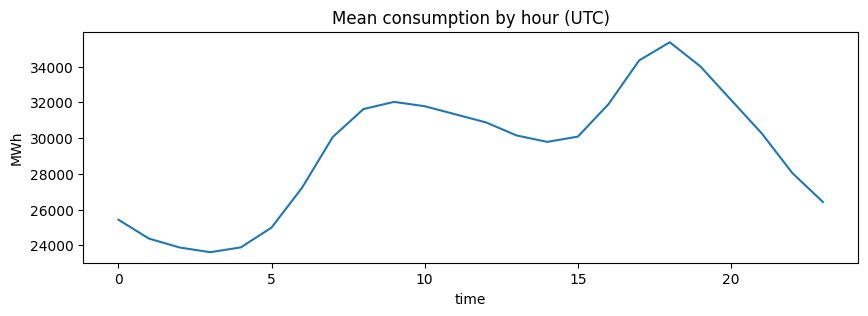

In [20]:
profile = ts["consumption_mwh"].groupby(ts.index.hour).mean()
dow_hour = ts["consumption_mwh"].groupby([ts.index.dayofweek, ts.index.hour]).mean().unstack()
print(dow_hour.iloc[:, [0, 6, 12, 18, 23]].round(0))
profile.plot(title="Mean consumption by hour (UTC)"); plt.ylabel("MWh"); plt.show()

## Year-on-year comparison with a pivot

Pivot on `year` × `dayofyear` (or month) to compare seasons side by side.

year      2022      2023
doy                     
1     734094.0  721736.0
2     728994.0  776459.0
3     764537.0  757244.0
YoY change by month (%):
time   2023-01-01 00:00:00+00:00  2023-02-01 00:00:00+00:00  2023-03-01 00:00:00+00:00  2023-04-01 00:00:00+00:00  \
yoy_%                       -0.5                        0.3                       -1.7                        0.8   

time   2023-05-01 00:00:00+00:00  2023-06-01 00:00:00+00:00  2023-07-01 00:00:00+00:00  2023-08-01 00:00:00+00:00  \
yoy_%                        0.4                       -0.2                       -1.5                        0.1   

time   2023-09-01 00:00:00+00:00  2023-10-01 00:00:00+00:00  2023-11-01 00:00:00+00:00  2023-12-01 00:00:00+00:00  
yoy_%                       -0.1                        0.6                       -3.1                       -2.1  


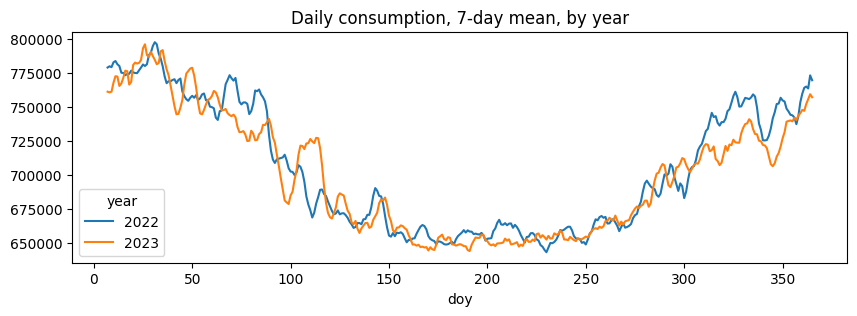

In [21]:
d = ts["consumption_mwh"].resample("D").sum()
yoy = pd.DataFrame({"year": d.index.year, "doy": d.index.dayofyear, "mwh": d.values}).pivot(
    index="doy", columns="year", values="mwh")
print(yoy.head(3).round(0))
print("YoY change by month (%):")
m = ts["consumption_mwh"].resample("MS").sum()
print((m.pct_change(12).dropna() * 100).round(1).to_frame("yoy_%").T)
yoy.rolling(7).mean().plot(title="Daily consumption, 7-day mean, by year"); plt.show()

## `between_time` / `at_time`

Select intraday windows on a DatetimeIndex regardless of the date (peak hours, delivery blocks).

In [22]:
peak = ts.between_time("16:00", "19:00")            # inclusive both ends by default
print("peak rows:", len(peak), "| mean peak price %.1f vs all %.1f" % (peak.price_eur_mwh.mean(), ts.price_eur_mwh.mean()))
ts.at_time("12:00").head(2).round(1)

peak rows: 2920 | mean peak price 129.1 vs all 98.5


,consumption_mwh,temp_c,wind_ms,solar_wm2,price_eur_mwh
time,,,,,
2022-01-01 12:00:00+00:00,32122.3,3.6,6.4,44.5,111.2
2022-01-02 12:00:00+00:00,31796.2,6.0,9.1,84.2,89.1


## Business days

`pd.bdate_range` skips weekends; add holidays via `freq="C", holidays=[...]`. For GB power, holidays
matter as much as weekends (demand looks like a Sunday). A manual list is often the most transparent.

In [23]:
gb_holidays = pd.to_datetime([
    "2022-01-03", "2022-04-15", "2022-04-18", "2022-05-02", "2022-06-02", "2022-06-03",
    "2022-08-29", "2022-09-19", "2022-12-26", "2022-12-27",
    "2023-01-02", "2023-04-07", "2023-04-10", "2023-05-01", "2023-05-08", "2023-05-29",
    "2023-08-28", "2023-12-25", "2023-12-26",
])
bdays = pd.bdate_range("2022-01-01", "2022-01-31", freq="C", holidays=gb_holidays)
print(len(bdays), "business days in Jan 2022 (Mon 3rd excluded)")
print(bdays[:3])

20 business days in Jan 2022 (Mon 3rd excluded)
DatetimeIndex(['2022-01-04', '2022-01-05', '2022-01-06'], dtype='datetime64[ns]', freq='C')


## A calendar-feature block you can paste anywhere

Derive everything from the UTC index converted to local time once. Keep the target in UTC.

In [24]:
def calendar_features(index_utc, tz="Europe/London", holidays=None):
    loc = index_utc.tz_convert(tz)
    out = pd.DataFrame(index=index_utc)
    out["hour"] = loc.hour
    out["dow"] = loc.dayofweek
    out["month"] = loc.month
    out["doy"] = loc.dayofyear
    out["is_weekend"] = (loc.dayofweek >= 5).astype(int)
    hol = pd.DatetimeIndex(holidays) if holidays is not None else pd.DatetimeIndex([])
    out["is_holiday"] = pd.Series(loc.normalize().tz_localize(None), index=index_utc).isin(hol).astype(int).values
    out["is_workday"] = ((out.is_weekend == 0) & (out.is_holiday == 0)).astype(int)
    # cyclical encodings for linear models
    out["hour_sin"] = np.sin(2 * np.pi * out.hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out.hour / 24)
    return out

cal = calendar_features(ts.index, holidays=gb_holidays)
print(cal["is_holiday"].sum(), "holiday hours")
cal.loc["2022-06-02 22:00":"2022-06-03 01:00"]          # note local hour vs UTC index (BST)

456 holiday hours


,hour,dow,month,doy,is_weekend,is_holiday,is_workday,hour_sin,hour_cos
time,,,,,,,,,
2022-06-02 22:00:00+00:00,23,3,6,153,0,1,0,-0.258819,0.965926
2022-06-02 23:00:00+00:00,0,4,6,154,0,1,0,0.000000,1.000000
2022-06-03 00:00:00+00:00,1,4,6,154,0,1,0,0.258819,0.965926
2022-06-03 01:00:00+00:00,2,4,6,154,0,1,0,0.500000,0.866025


## Time-series checklist

- Index sorted? unique? tz-aware? frequency regular? (`is_monotonic_increasing`, `is_unique`, `infer_freq`)
- Gaps found and handled explicitly (`reindex`) — not silently skipped by row-based `shift`/`rolling`.
- Every feature at time *t* uses only data at *t-1* or earlier: `shift(1)` before `rolling`.
- Resampled bars labelled by the **start** of the interval (or you know exactly why not).
- Energy summed, prices/temperature averaged.
- Local-time features derived from UTC; DST days checked (23 / 25 local hours).
- `pct_change` only on strictly positive series.